<a href="https://colab.research.google.com/github/JediKnight007/Computer-Vision-Final-Project/blob/main/segmentation_integrated_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

# Define a path in Google Drive for the Hugging Face datasets cache
gdrive_hf_cache_dir = '/content/drive/MyDrive/hf_datasets_cache'

# Create the directory if it doesn't exist
os.makedirs(gdrive_hf_cache_dir, exist_ok=True)

print(f"Hugging Face datasets cache directory set to: {gdrive_hf_cache_dir}")

Hugging Face datasets cache directory set to: /content/drive/MyDrive/hf_datasets_cache


In [3]:
import os

# Construct the path to the Hugging Face datasets cache directory
hf_cache_dir = os.path.expanduser('~/.cache/huggingface/datasets')

print(f"Contents of the Hugging Face datasets cache directory ({hf_cache_dir}):")
!ls -F {hf_cache_dir}


Contents of the Hugging Face datasets cache directory (/root/.cache/huggingface/datasets):
ls: cannot access '/root/.cache/huggingface/datasets': No such file or directory


### Disk Space Management

If you run into disk space issues, especially when working with large datasets, the Hugging Face `datasets` library can consume a lot of space caching files. You can clear this cache using the following command. Be cautious, as this will remove all downloaded datasets from your cache, and you'll need to re-download them if you use them again.

In [4]:
# Clear the Hugging Face datasets cache
import os
import shutil

hf_cache_dir = os.path.expanduser('~/.cache/huggingface/datasets')

if os.path.exists(hf_cache_dir):
    print(f"Clearing Hugging Face datasets cache at: {hf_cache_dir}")
    shutil.rmtree(hf_cache_dir)
    print("Cache cleared.")
else:
    print(f"Hugging Face datasets cache directory not found at: {hf_cache_dir}")

# You can also check current disk usage
print("\nDisk usage after clearing cache:")
!df -h /content

Hugging Face datasets cache directory not found at: /root/.cache/huggingface/datasets

Disk usage after clearing cache:
Filesystem      Size  Used Avail Use% Mounted on
overlay         236G   43G  193G  19% /


In [5]:
# colab setting
!pip install GraphRicciCurvature scikit-learn scikit-image tqdm scipy

import networkx as nx
import numpy as np
import math
import time

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

import logging
logging.basicConfig(format='%(levelname)s:%(message)s', level=logging.ERROR)

from GraphRicciCurvature.OllivierRicci import OllivierRicci
from GraphRicciCurvature.FormanRicci import FormanRicci
from GraphRicciCurvature.util import cut_graph_by_cutoff

import community.community_louvain as community_louvain

from sklearn import metrics
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, jaccard_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler
from scipy.stats import skew, kurtosis
from scipy import ndimage
from skimage.filters import threshold_otsu
from tqdm import tqdm

import pandas as pd
import seaborn as sns
from collections import Counter


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 131.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 76.9 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
access 1.1.10.post3 requires scipy>=1.14.1, but you have scipy 1.13.1 which is incompatible.
tsfresh 0.21.1 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.


In [6]:
import numpy as np
from datasets import load_dataset

def load_mnist_arrays(split="train", cache_dir=None):
    """
    Load MNIST from Hugging Face and return images as (N, 28, 28) float32 arrays
    normalized to [0, 1], along with integer labels.
    """
    dataset = load_dataset("mnist", split=split, cache_dir=cache_dir)

    images = np.array([np.array(sample["image"]) for sample in dataset], dtype=np.float32)
    labels = np.array([sample["label"] for sample in dataset], dtype=np.int64)

    images /= 255.0  # normalize to [0, 1]

    return images, labels


if __name__ == "__main__":
    # Make sure gdrive_hf_cache_dir is defined from the previous cell if you want to use Drive cache
    train_images, train_labels = load_mnist_arrays("train", cache_dir=gdrive_hf_cache_dir)
    test_images, test_labels = load_mnist_arrays("test", cache_dir=gdrive_hf_cache_dir)

    print(f"Train: {train_images.shape}, dtype={train_images.dtype}, min={train_images.min():.2f}, max={train_images.max():.2f}")
    print(f"Test:  {test_images.shape}, dtype={test_images.dtype}, min={test_images.min():.2f}, max={test_images.max():.2f}")
    print(f"Label range: {train_labels.min()} - {train_labels.max()}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Train: (60000, 28, 28), dtype=float32, min=0.00, max=1.00
Test:  (10000, 28, 28), dtype=float32, min=0.00, max=1.00
Label range: 0 - 9


In [7]:
# ── Module-level pixel distance / similarity functions ────────────────────────
# Preserved exactly from initial.py

def _euclidean_distance(a: float, b: float) -> float:
    """Euclidean distance between two scalar grayscale pixel values."""
    return abs(a - b)


def _cosine_similarity(a: float, b: float) -> float:
    """
    Cosine similarity between two scalar pixel values.

    NOTE: for scalars in [0,1] this is always 1.0 when both are nonzero,
    so it only distinguishes zero vs non-zero pixels. Consider using
    (1 - similarity) as the edge weight to match the euclidean convention
    where similar pixels have low weight.
    """
    if a == 0 and b == 0:
        return 1.0  # Both pixels are black — identical by convention
    return (a * b) / (np.sqrt(a ** 2) * np.sqrt(b ** 2))


# ── InitialSegmenter ──────────────────────────────────────────────────────────

class InitialSegmenter:
    """
    Pixel-graph segmenter using Ollivier-Ricci curvature and Ricci flow.

    Parameters
    ----------
    pixel_dist_function : "euclidean" | "cosine"
        Edge-weight function between adjacent pixel values.
    cutoff : float
        In segment_graph(): edges with ricciCurvature BELOW cutoff are
        removed (hyperbolic / boundary edges). Edges above cutoff are kept.
        Matches cut_graph_by_cutoff() convention from GraphRicciCurvature.

    Fixes applied vs initial.py
    ---------------------------
    1. segment_graph() now removes edges BELOW cutoff (was above — inverted).
    2. segment() now calls compute_ricci_curvature() before compute_ricci_flow().
    """

    def __init__(self, pixel_dist_function: str = "euclidean", cutoff: float = 0.1):
        self.cutoff = cutoff
        match pixel_dist_function:
            case "euclidean":
                self._dist_func = _euclidean_distance
            case "cosine":
                self._dist_func = _cosine_similarity
            case _:
                raise ValueError(f"Unsupported pixel distance function: {pixel_dist_function}")

    def image_to_graph(self, image: np.ndarray) -> nx.Graph:
        """
        Convert a (H,W) greyscale or (H,W,C) image to a 4-connected pixel graph.
        Node attrs: value (float [0,1]), row (int), col (int)
        Edge attrs: weight = self._dist_func(pixel_a, pixel_b)
        """
        if image.ndim == 3 and image.shape[2] == 1:
            image = image.squeeze(axis=2)
        if image.ndim == 3:
            H, W, _ = image.shape
            grey = image.mean(axis=2)
        else:
            H, W = image.shape
            grey = image

        G = nx.Graph()
        for r in range(H):
            for c in range(W):
                nid = r * W + c
                G.add_node(nid, value=float(grey[r, c]), row=r, col=c)
        for r in range(H):
            for c in range(W):
                nid = r * W + c
                val = G.nodes[nid]["value"]
                if c + 1 < W:
                    rid = nid + 1
                    G.add_edge(nid, rid,
                               weight=self._dist_func(val, G.nodes[rid]["value"]))
                if r + 1 < H:
                    bid = nid + W
                    G.add_edge(nid, bid,
                               weight=self._dist_func(val, G.nodes[bid]["value"]))
        return G

    def segment_graph(self, G: nx.Graph,
                      attribute: str = "ricciCurvature") -> nx.Graph:
        """
        Remove edges whose curvature is BELOW self.cutoff.
        Hyperbolic (boundary) edges are cut; parabolic (interior) edges kept.
        FIX: initial.py removed edges ABOVE cutoff — opposite of correct logic.
        """
        H = G.copy()
        H.remove_edges_from(
            [(u, v) for u, v, d in H.edges(data=True)
             if d.get(attribute, 0.0) < self.cutoff]
        )
        return H

    def graph_to_segmentation_map(self, G: nx.Graph,
                                  H: int = 28, W: int = 28) -> np.ndarray:
        """Connected components of G → (H, W) int32 segmentation map."""
        seg = np.full((H, W), -1, dtype=np.int32)
        for cid, component in enumerate(nx.connected_components(G)):
            for node in component:
                d = G.nodes[node]
                seg[d["row"], d["col"]] = cid
        return seg

    def segment(self, image: np.ndarray,
                flow_iterations: int = 15) -> np.ndarray:
        """
        End-to-end: image → graph → ORC curvature → Ricci flow
                    → segment_graph → (H, W) int32 segmentation map.
        FIX: initial.py skipped compute_ricci_curvature() before flow.
        """
        if image.ndim == 3 and image.shape[2] == 1:
            image = image.squeeze(axis=2)
        H, W = image.shape[:2]
        G   = self.image_to_graph(image)
        orc = OllivierRicci(G, verbose="ERROR")
        orc.compute_ricci_curvature()        # was missing in initial.py
        orc.compute_ricci_flow(iterations=flow_iterations)
        return self.graph_to_segmentation_map(self.segment_graph(orc.G), H, W)


# ── Convenience wrappers (keep all downstream cells working unchanged) ─────────
_seg = InitialSegmenter(pixel_dist_function="euclidean", cutoff=0.1)

def image_to_graph(image: np.ndarray) -> nx.Graph:
    """Thin wrapper around InitialSegmenter.image_to_graph() (euclidean)."""
    return _seg.image_to_graph(image)

def graph_to_image(G: nx.Graph, H: int = 28, W: int = 28) -> np.ndarray:
    """Reconstruct (H,W) float32 image from node value attributes."""
    img = np.zeros((H, W), dtype=np.float32)
    for _, d in G.nodes(data=True):
        img[d["row"], d["col"]] = d["value"]
    return img


# ── Smoke test ────────────────────────────────────────────────────────────────
if "train_images" in dir():
    G_test = image_to_graph(train_images[0])
    print(f"Nodes: {G_test.number_of_nodes()}, Edges: {G_test.number_of_edges()}")
    print(f"Reconstruction error: {np.abs(train_images[0] - graph_to_image(G_test)).max():.6f}")
    print(f"_euclidean_distance(0.3, 0.7) = {_euclidean_distance(0.3, 0.7):.4f}  (expect 0.4)")
    print(f"_cosine_similarity(0.0, 0.0)  = {_cosine_similarity(0.0, 0.0):.4f}   (expect 1.0)")
    print("InitialSegmenter OK")
else:
    print("Run the data-loading cells first, then re-run this cell.")


Nodes: 784, Edges: 1512
Reconstruction error: 0.000000
_euclidean_distance(0.3, 0.7) = 0.4000  (expect 0.4)
_cosine_similarity(0.0, 0.0)  = 1.0000   (expect 1.0)
InitialSegmenter OK


## InitialSegmenter — single-image demo

Verifies both fixes: `compute_ricci_curvature()` is now called before flow, and `segment_graph()` removes edges **below** the cutoff (boundary edges), not above it. Expect to see multiple spatially coherent components.

Running InitialSegmenter.segment() on digit 5 ...
  Components found : 652
  Seg map shape    : (28, 28), dtype=int32


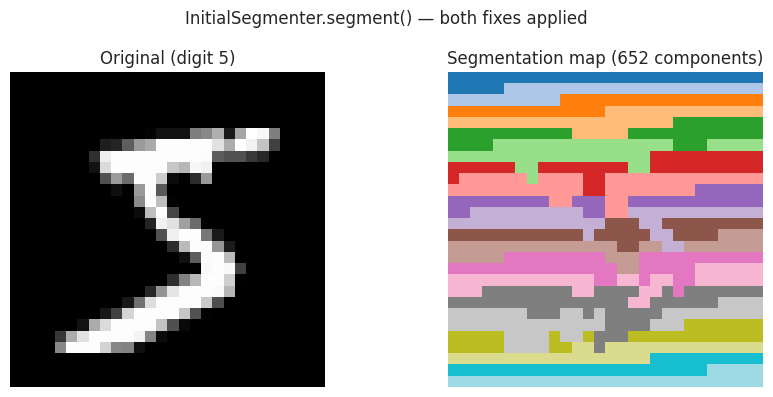

In [8]:
seg          = InitialSegmenter(pixel_dist_function="euclidean", cutoff=0.1)
sample_img   = train_images[0]
sample_label = train_labels[0]

print(f"Running InitialSegmenter.segment() on digit {sample_label} ...")
seg_map = seg.segment(sample_img, flow_iterations=10)

n_components = len(np.unique(seg_map))
print(f"  Components found : {n_components}")
print(f"  Seg map shape    : {seg_map.shape}, dtype={seg_map.dtype}")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(sample_img, cmap="gray")
axes[0].set_title(f"Original (digit {sample_label})")
axes[0].axis("off")
axes[1].imshow(seg_map, cmap="tab20")
axes[1].set_title(f"Segmentation map ({n_components} components)")
axes[1].axis("off")
plt.suptitle("InitialSegmenter.segment() — both fixes applied", fontsize=12)
plt.tight_layout()
plt.show()


### How to get and use your Hugging Face Token

1.  **Generate a token:** Go to your Hugging Face settings page (e.g., `huggingface.co/settings/tokens`). Click on "New token" and create a token with at least "read" access.
2.  **Add token to Colab secrets:** In Colab, click the "🔑 Secrets" icon on the left sidebar. Add a new secret named `HF_TOKEN` and paste your Hugging Face token as its value.
3.  **Log in to Hugging Face:** Use the following code to log in to Hugging Face in your Colab session. This will allow the `datasets` library to use your token for authentication.

In [10]:
from huggingface_hub import login
from google.colab import userdata

# Retrieve the HF_TOKEN from Colab secrets
hf_token = userdata.get('HF_TOKEN')

# Log in to Hugging Face
login(token=hf_token)

print("Successfully logged in to Hugging Face.")

Successfully logged in to Hugging Face.


After successfully logging in, you should be able to rerun the cell to load the `ILSVRC/imagenet-1k` dataset.

### Final Project Proposal Answers

**Team name:** Ricci Flow Image Analysis

---

**What is your project idea?**

Our project aims to explore the application of discrete differential geometric concepts, specifically Ollivier-Ricci curvature and Ricci flow, to image processing tasks. We will represent grayscale images as graphs, where pixels are nodes and adjacent pixels are connected by edges. The edge weights will be determined by the Euclidean distance between pixel intensities. We will then compute the Ricci curvature of these graphs and apply Ricci flow to modify the graph structure, with the goal of understanding how these geometric transformations can be used for tasks such as image segmentation, denoising, or feature enhancement.

---

**What is the socio-historical context that this project lives in?**

This project sits at the intersection of geometric graph theory, discrete differential geometry, and computer vision. Traditional image processing heavily relies on methods derived from continuous calculus (e.g., gradients, Laplacians). However, discrete analogues, particularly those inspired by Riemannian geometry, have gained traction for analyzing discrete structures like graphs. Ollivier-Ricci curvature, introduced by Ollivier in 2009, provides a metric-space notion of curvature applicable to graphs, offering a novel way to understand local and global graph properties. Its application to images, as discrete grids, opens new avenues for image analysis by leveraging the rich mathematical framework of curvature and flow for tasks typically addressed by other methods.

---

**Please list three stakeholders that your project could impact, and describe how it could impact them.**

1.  **Researchers in Geometric Deep Learning/Graph Neural Networks:** This project provides a practical demonstration and potential testbed for applying discrete geometric concepts to real-world data like images. It could inform the development of new graph-based learning architectures or contribute to a deeper understanding of how geometric properties influence data representation.
2.  **Image Processing and Computer Vision Engineers:** The approach offers an alternative, potentially robust, method for fundamental image processing tasks. If successful in segmentation or denoising, it could complement or improve existing techniques, especially for complex or noisy images where traditional methods struggle.
3.  **Educators and Students in Applied Mathematics/Data Science:** This project serves as an excellent case study for teaching advanced mathematical concepts (differential geometry, graph theory) in a tangible, visual context. It demonstrates how abstract theories can be translated into practical algorithms for data analysis.

---

**What are the skills of the team members? Conduct a skill assessment!**

*   **Team member 1:** Strong in Python programming, data manipulation with NumPy and Pandas, experience with `networkx` for graph manipulation, and familiar with basic image processing concepts.
*   **Team member 2:** Solid understanding of graph theory, discrete mathematics, and has a background in numerical methods and scientific computing. Experience with `matplotlib` for data visualization.
*   **Team member 3:** Proficient in machine learning fundamentals, data loading from various sources (e.g., Hugging Face `datasets`), and interpreting complex results. Experience with `scikit-learn` for evaluation metrics.

---

**What data will you use?**

We will primarily use the **MNIST dataset** of handwritten digits (28x28 grayscale images) for initial development and proof-of-concept. The `load_mnist_arrays` function is already implemented in the notebook. If computational resources allow and the authentication issue for gated datasets is resolved, we aim to extend our analysis to grayscale versions of images from the **ImageNet-1k dataset** using the `load_imagenet_arrays` function, to test scalability and robustness on more complex, higher-resolution images.

---

**What software/hardware will you use?**

*   **Software:**
    *   **Python:** The primary programming language.
    *   **NetworkX:** For graph construction and manipulation.
    *   **GraphRicciCurvature:** The core library for computing Ollivier-Ricci curvature and Ricci flow.
    *   **NumPy:** For numerical operations and array manipulation.
    *   **Matplotlib:** For visualization of graphs, images, and curvature distributions.
    *   **Hugging Face `datasets`:** For loading image datasets (e.g., MNIST, ImageNet).
    *   **Google Colab:** The development environment for coding and execution.
*   **Hardware:**
    *   Google Colab's standard computing environment, which includes CPUs and potentially GPUs for more computationally intensive tasks if needed.

---

**Who will do what?**

*   **Team member 1:** Will focus on data preprocessing, converting images to graphs (`image_to_graph`), and ensuring data pipelines are efficient. They will also contribute to implementing specific image processing tasks (e.g., thresholding for segmentation) based on Ricci curvature outputs.
*   **Team member 2:** Will be responsible for the core graph analysis, including applying `OllivierRicci` methods (`compute_ricci_curvature`, `compute_ricci_flow`) and exploring different parameters and iterations for the Ricci flow. They will also research theoretical aspects and potential adaptations of the curvature concept.
*   **Team member 3:** Will handle result visualization and analysis (`show_results`, `visualise_graph`), interpreting the impact of Ricci curvature and flow on image features. They will also be responsible for any quantitative evaluation (e.g., using metrics from `scikit-learn`) if we pursue specific tasks like segmentation quality.

---

**How will you know whether you have made progress? What will you measure?**

We will track progress through several indicators:

*   **Successful graph construction:** Ability to reliably convert various images into NetworkX graphs.
*   **Curvature computation:** Successful calculation and visualization of Ricci curvature for edges.
*   **Ricci flow application:** Observing changes in edge weights and image appearance after applying Ricci flow, with visual confirmation that the flow is indeed smoothing or highlighting features as expected.
*   **Qualitative assessment:** Visual inspection of images before and after Ricci flow to identify meaningful structural changes (e.g., clearer boundaries, reduced noise).
*   **Quantitative metrics (if applicable):** If we apply the technique to a specific task like segmentation, we will measure metrics like Adjusted Rand Index (ARI) or other clustering/segmentation performance indicators to evaluate the effectiveness of curvature-based methods compared to baselines.
*   **Documentation:** Clear progress in documenting our findings, observations, and computational challenges.

---

**What technical problems do you foresee or have?**

*   **Computational Intensity:** Calculating Ollivier-Ricci curvature and especially running Ricci flow can be computationally expensive for larger images, potentially leading to long processing times even for modest image sizes. Optimizing the `GraphRicciCurvature` library usage or exploring approximations might be necessary.
*   **Parameter Tuning:** Determining optimal parameters for Ricci flow (e.g., number of iterations, step size, and initial graph construction) can be challenging and might require extensive experimentation.
*   **Interpretation of Curvature:** Relating the abstract values of Ricci curvature directly to intuitive image features or human perception can be non-trivial and require careful analysis.
*   **Gated Dataset Access:** We already encountered an issue accessing the ImageNet dataset due to authentication requirements, which needs to be fully resolved to experiment with larger-scale data.

---

**Is there anything that we can do to help? E.G., resources, equipment.**

*   **Computational Resources:** Access to more powerful computing resources (e.g., Colab Pro GPU instances if available and beneficial for graph computations) would be highly valuable, especially for scaling up to larger images or more complex graph structures.
*   **Expert Guidance:** Any insights or pointers regarding the `GraphRicciCurvature` library, alternative efficient graph processing libraries, or advanced techniques in discrete differential geometry applied to image analysis would be greatly appreciated.
*   **Dataset Access:** Confirmation or assistance in resolving issues with accessing gated datasets like ImageNet through Hugging Face, ensuring we can test on diverse and larger image sets.

In [11]:
# Create a dummy file for demonstration
!echo "This is a test file." > test_delete.txt

# Verify the file was created
!ls

# Delete the file
!rm test_delete.txt

# Verify the file is deleted
!ls

drive  sample_data  test_delete.txt
drive  sample_data


## Visualisation Functions


In [12]:
def show_results(G, curvature="ricciCurvature", label=None):
    """
    Given a NetworkX graph, graphs the histogram of Ricci curvatures,
    the histogram of edge weights, and a scatterplot of edge properties

    Parametres
    ----------
    G: NetworkX graph
       the graph whose properties we want to compute
    """
    print(f"Number of clusters = {len(list(nx.connected_components(G)))}")

    # Print the first five results
    print("Graph, first 5 edges: ")
    for n1,n2 in list(G.edges())[:5]:
        print("Ricci curvature of edge (%s,%s) is %f" % (n1 ,n2, G[n1][n2][curvature]))

    # Plot the histogram of Ricci curvatures
    plt.subplot(3, 1, 1)
    ricci_curvtures = nx.get_edge_attributes(G, curvature).values()
    plt.hist(ricci_curvtures,bins=100,label=label)
    plt.xlabel('Ricci curvature')
    plt.title("Histogram of Ricci Curvatures")

    # Plot the histogram of edge weights
    plt.subplot(3, 1, 2)
    weights = nx.get_edge_attributes(G, "weight").values()
    plt.hist(weights,bins=100,label=label)
    plt.xlabel('Edge weight')
    plt.title("Histogram of Edge weights")

    # Create scatter plot
    plt.subplot(3, 1, 3)
    plt.scatter(weights, ricci_curvtures,label=label)
    # Add labels and title
    plt.xlabel('Edge Weight')
    plt.ylabel('Ricci Curvature')
    plt.title('Scatter Plot of Edge Properties')

    plt.tight_layout()
    plt.legend()

mnist/train-00000-of-00001.parquet:   0%|          | 0.00/15.6M [00:00<?, ?B/s]

mnist/test-00000-of-00001.parquet:   0%|          | 0.00/2.60M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

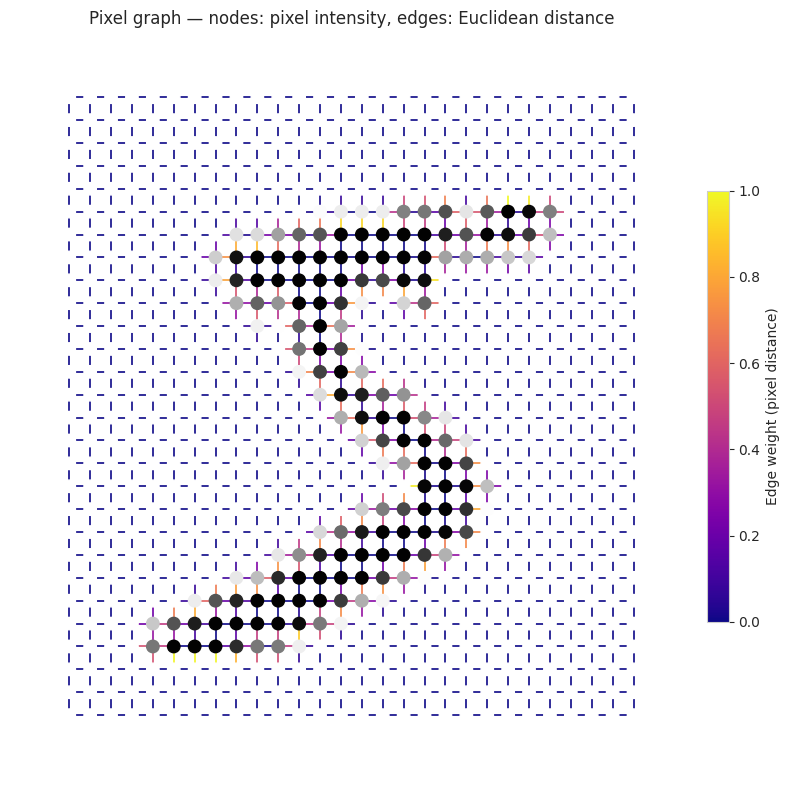

In [13]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors


def visualise_graph(G: nx.Graph, H: int = 28, W: int = 28, figsize: tuple = (8, 8), edge_weight = "weight"):
    """
    Visualise a pixel graph produced by image_to_graph.

    - Each node is drawn as a circle coloured by its pixel intensity (grayscale).
    - Each edge is coloured by its weight (Euclidean distance between pixel values),
      from dark purple (similar) to yellow (dissimilar), using the 'plasma' colormap.

    Args:
        G:       Graph from image_to_graph.
        H, W:    Image dimensions (default 28x28).
        figsize: Matplotlib figure size.
    """
    # Position nodes at their pixel grid coordinates (col, inverted row)
    pos = {n: (data["col"], H - 1 - data["row"]) for n, data in G.nodes(data=True)}

    node_colors = [1-data["value"] for _, data in G.nodes(data=True)]
    edge_weights = [data[edge_weight] for _, _, data in G.edges(data=True)]

    edge_cmap = cm.plasma
    edge_norm = mcolors.Normalize(vmin=0.0, vmax=1.0)
    edge_colors = [edge_cmap(edge_norm(w)) for w in edge_weights]

    fig, ax = plt.subplots(figsize=figsize)

    nx.draw(
        G,
        pos=pos,
        ax=ax,
        node_size=80,
        node_color=node_colors,
        cmap="gray",
        vmin=0.0,
        vmax=1.0,
        edge_color=edge_colors,
        width=1.2,
        with_labels=False,
    )

    # Colourbar for edge weights
    sm_edges = cm.ScalarMappable(cmap=edge_cmap, norm=edge_norm)
    sm_edges.set_array([])
    cbar = fig.colorbar(sm_edges, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("Edge weight (pixel distance)", fontsize=10)

    ax.set_title("Pixel graph — nodes: pixel intensity, edges: Euclidean distance")
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    images, labels = load_mnist_arrays("train")
    G = image_to_graph(images[0])
    visualise_graph(G)


## Data Processing Start

INFO:GraphRicciCurvature:0.153742 secs for Ricci curvature computation.


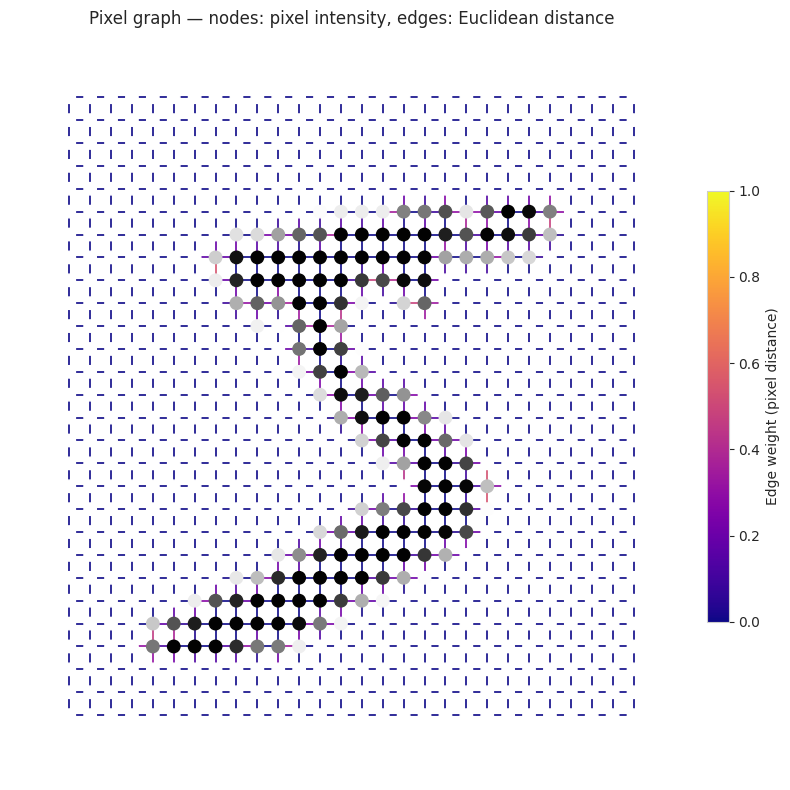

In [14]:
curvature_label = "ricciCurvature"

orc = OllivierRicci(G, verbose='INFO')
orc.compute_ricci_curvature()
visualise_graph(orc.G, edge_weight=curvature_label)

Number of clusters = 1
Graph, first 5 edges: 
Ricci curvature of edge (0,1) is 0.000000
Ricci curvature of edge (0,28) is 0.000000
Ricci curvature of edge (1,2) is 0.000000
Ricci curvature of edge (1,29) is 0.000000
Ricci curvature of edge (2,3) is 0.000000


/tmp/ipykernel_2089/411615512.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


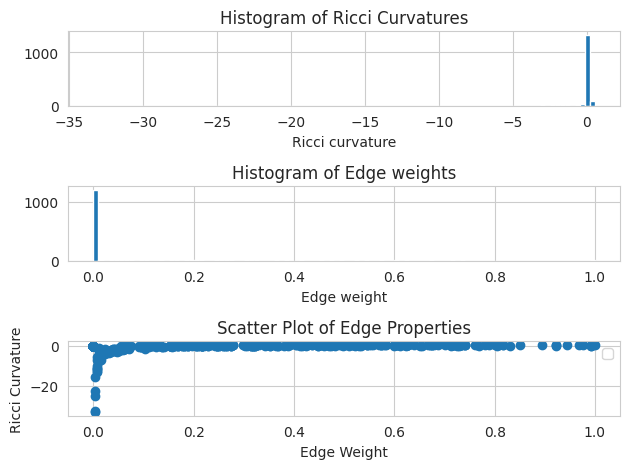

In [15]:
show_results(orc.G)

In [16]:
orc.compute_ricci_flow(iterations=1)

INFO:GraphRicciCurvature:No ricciCurvature detected, compute original_RC...
INFO:GraphRicciCurvature:0.255462 secs for Ricci curvature computation.
INFO:GraphRicciCurvature: === Ricci flow iteration 0 === 
--- Logging error ---
Traceback (most recent call last):
  File "/usr/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/

Number of clusters = 1
Graph, first 5 edges: 
Ricci curvature of edge (0,1) is 0.000000
Ricci curvature of edge (0,28) is 0.000000
Ricci curvature of edge (1,2) is 0.000000
Ricci curvature of edge (1,29) is 0.000000
Ricci curvature of edge (2,3) is 0.000000


/tmp/ipykernel_2089/411615512.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


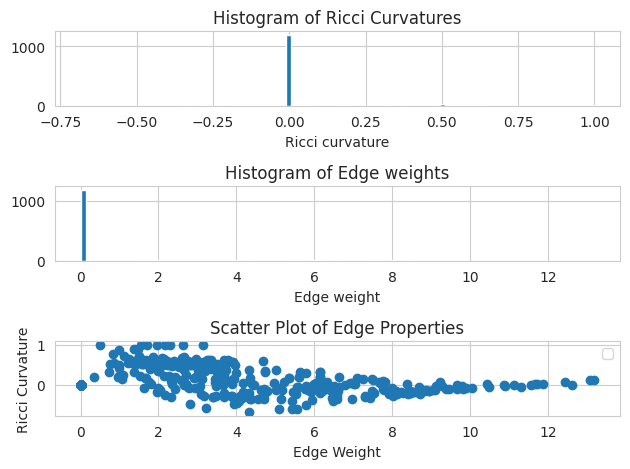

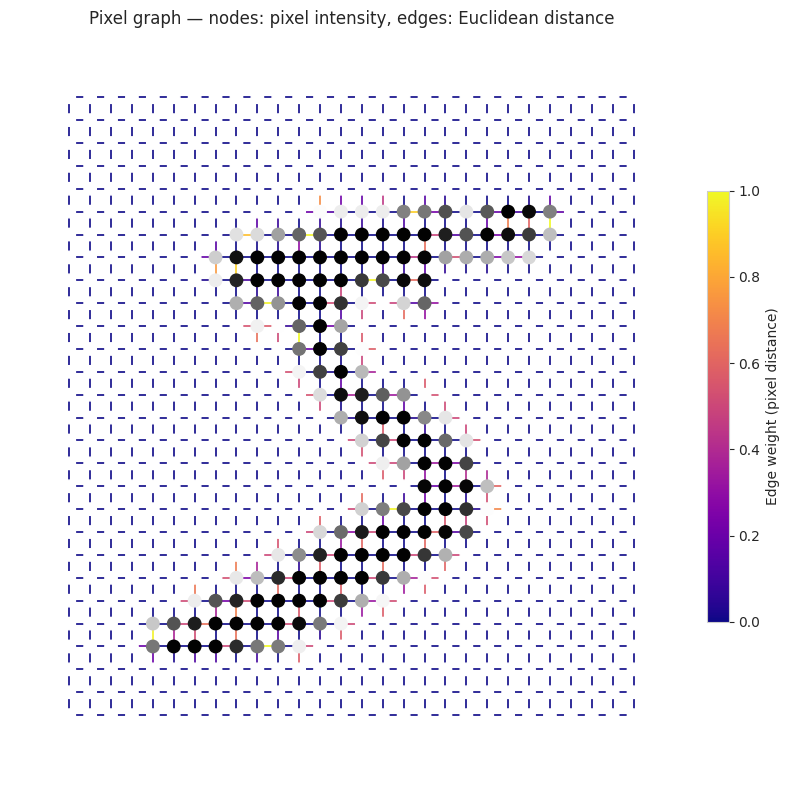

In [17]:
show_results(orc.G)
visualise_graph(orc.G, edge_weight=curvature_label)

INFO:GraphRicciCurvature:original_RC detected, continue to refine the ricci flow.
INFO:GraphRicciCurvature: === Ricci flow iteration 0 === 
--- Logging error ---
Traceback (most recent call last):
  File "/usr/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, i

Number of clusters = 1
Graph, first 5 edges: 
Ricci curvature of edge (0,1) is 0.000000
Ricci curvature of edge (0,28) is 0.000000
Ricci curvature of edge (1,2) is 0.000000
Ricci curvature of edge (1,29) is 0.000000
Ricci curvature of edge (2,3) is 0.000000


/tmp/ipykernel_2089/411615512.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


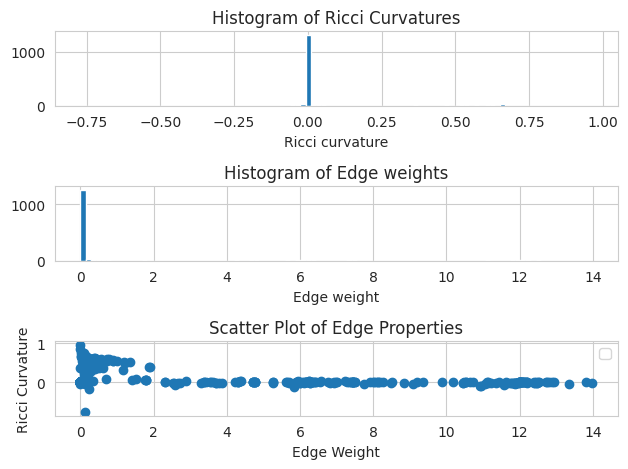

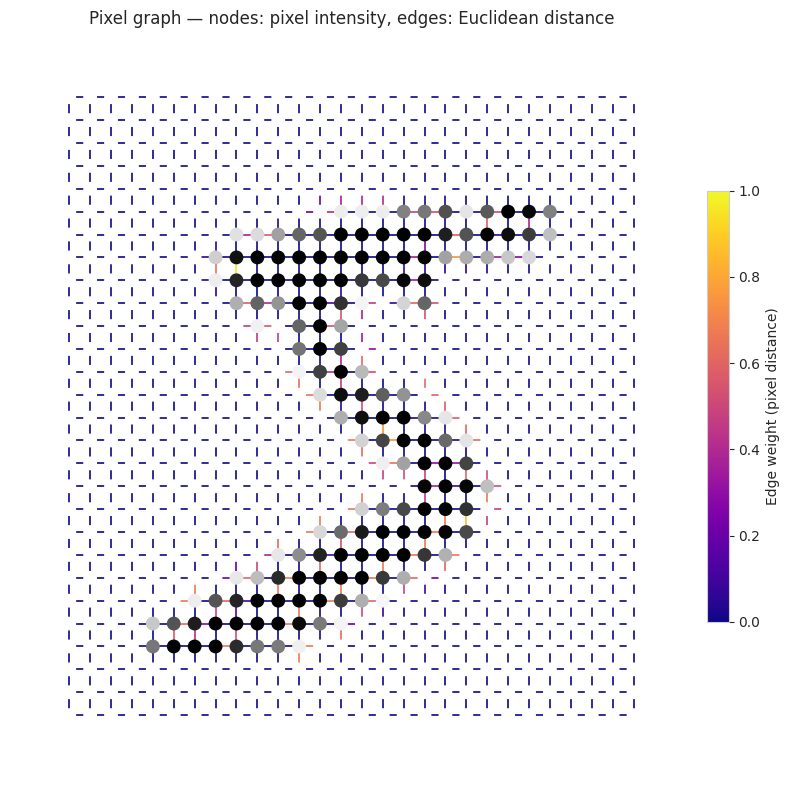

In [18]:
orc.compute_ricci_flow(iterations=4)

show_results(orc.G)
visualise_graph(orc.G, edge_weight=curvature_label)

## Segmentation via Ricci Curvature Cutoff

After Ricci flow, edges crossing region **boundaries** tend to have lower (more negative) curvature,
while edges inside uniform regions stay high. We exploit this by removing edges below a threshold,
then reading off connected components as segments (digit vs. background).

Pipeline:
1. Sweep curvature cutoffs and count resulting components
2. Pick the cutoff that gives exactly 2 components (digit + background)
3. Convert each component back to a pixel mask and display

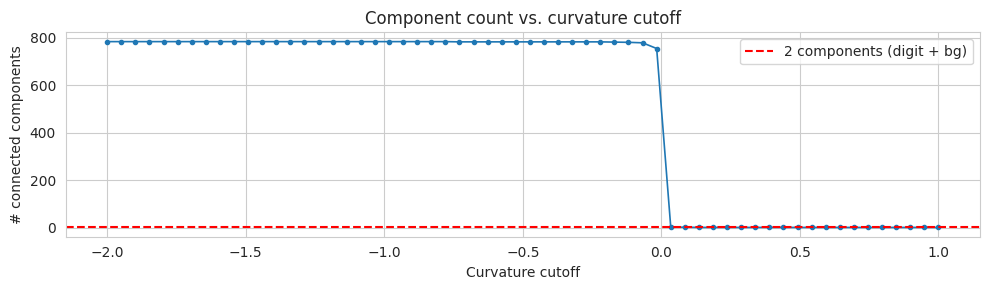

Cutoff values that yield exactly 2 components:
[0.03389830508474567, 0.08474576271186463]


In [19]:
def sweep_cutoff(G, curvature_attr='ricciCurvature', lo=-2.0, hi=1.0, steps=60):
    """
    For a range of curvature thresholds, remove edges whose curvature < threshold
    and count the resulting connected components.
    Returns:
        cutoffs  : list of threshold values tested
        n_comps  : list of component counts at each threshold
    """
    cutoffs = np.linspace(lo, hi, steps)
    n_comps = []
    for cutoff in cutoffs:
        G_cut = cut_graph_by_cutoff(G, cutoff=cutoff, weight=curvature_attr)
        n_comps.append(nx.number_connected_components(G_cut))
    return cutoffs.tolist(), n_comps


# Run sweep on the post-flow graph from orc.G (already computed above)
cutoffs, n_comps = sweep_cutoff(orc.G)

plt.figure(figsize=(10, 3))
plt.plot(cutoffs, n_comps, marker='o', markersize=3, linewidth=1.2)
plt.axhline(2, color='red', linestyle='--', label='2 components (digit + bg)')
plt.xlabel('Curvature cutoff')
plt.ylabel('# connected components')
plt.title('Component count vs. curvature cutoff')
plt.legend()
plt.tight_layout()
plt.show()

two_comp_cutoffs = [c for c, n in zip(cutoffs, n_comps) if n == 2]
print('Cutoff values that yield exactly 2 components:')
print(two_comp_cutoffs)

In [20]:
def segment_by_curvature(G, cutoff, curvature_attr='ricciCurvature', H=28, W=28):
    """
    Cut the graph at `cutoff` and return:
      seg_map  : (H, W) int array — each pixel labelled with its component index
      fg_mask  : (H, W) bool array — True for the foreground (digit) component
      G_cut    : the cut graph
    """
    G_cut = cut_graph_by_cutoff(G, cutoff=cutoff, weight=curvature_attr)
    components = list(nx.connected_components(G_cut))

    seg_map = np.zeros((H, W), dtype=np.int32)
    for label_idx, component in enumerate(components):
        for node in component:
            r = G.nodes[node]['row']
            c = G.nodes[node]['col']
            seg_map[r, c] = label_idx

    # Foreground = component with highest mean pixel intensity
    best_label, best_mean = 0, -1.0
    for label_idx, component in enumerate(components):
        mean_val = np.mean([G.nodes[n]['value'] for n in component])
        if mean_val > best_mean:
            best_mean = mean_val
            best_label = label_idx

    fg_mask = (seg_map == best_label)
    return seg_map, fg_mask, G_cut, best_label


# Pick middle cutoff from those that gave exactly 2 components
if two_comp_cutoffs:
    best_cutoff = two_comp_cutoffs[len(two_comp_cutoffs) // 2]
else:
    best_cutoff = -0.5
    print(f'No 2-component cutoff found — using fallback {best_cutoff}')

print(f'Segmenting with curvature cutoff = {best_cutoff:.4f}')
seg_map, fg_mask, G_cut, best_label = segment_by_curvature(orc.G, cutoff=best_cutoff)
print(f'Components found: {len(np.unique(seg_map))}')
print(f'Foreground pixels: {fg_mask.sum()} / {28*28}')

Segmenting with curvature cutoff = 0.0847
Components found: 2
Foreground pixels: 2 / 784


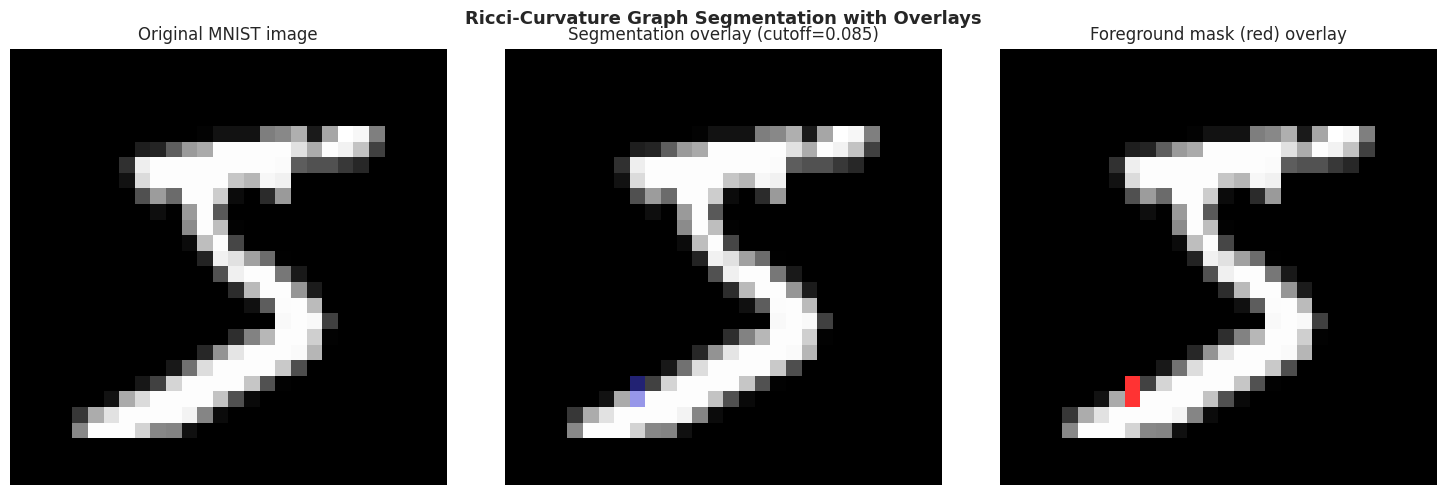

In [21]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np # Ensure numpy is imported for array operations

original_image = graph_to_image(orc.G)

fig, axes = plt.subplots(1, 3, figsize=(15, 5)) # Increased figsize for better visibility

# Plot 1: Original MNIST image
axes[0].imshow(original_image, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Original MNIST image')
axes[0].axis('off')

# Plot 2: Segmentation map overlaid on original image
# Create a blank RGBA image to draw the segmentation on
overlay_seg = np.zeros(original_image.shape + (4,)) # HxWx4 for RGBA
unique_labels = np.unique(seg_map)

# Define colors for segments. For 2 components, assume 0 is background and best_label is foreground.
# We want to highlight the foreground label from seg_map.
if len(unique_labels) == 2:
    # Determine background and foreground labels
    bg_label = unique_labels[0] if unique_labels[0] != best_label else unique_labels[1]
    fg_label = best_label

    # Background pixels remain transparent
    overlay_seg[seg_map == bg_label] = [0, 0, 0, 0]
    # Foreground pixels (digit) are colored semi-transparent blue
    overlay_seg[seg_map == fg_label] = [0.2, 0.2, 1.0, 0.4] # Semi-transparent blue

elif len(unique_labels) > 2: # For more complex cases with multiple segments
    cmap_base = plt.cm.tab20 # Use a diverse colormap for multiple segments
    for i, label in enumerate(unique_labels):
        color = list(cmap_base(i / len(unique_labels))) # Get color from colormap
        color[3] = 0.4 # Set alpha for transparency
        overlay_seg[seg_map == label] = color

# Base image
axes[1].imshow(original_image, cmap='gray', vmin=0, vmax=1)
# Overlay the colored segmentation
axes[1].imshow(overlay_seg)
axes[1].set_title(f'Segmentation overlay (cutoff={best_cutoff:.3f})')
axes[1].axis('off')


# Plot 3: Foreground mask overlaid in red on grayscale original (as before)
overlay_fg_red = np.stack([original_image]*3, axis=-1)
overlay_fg_red[fg_mask] = [1.0, 0.2, 0.2] # Red for foreground
axes[2].imshow(overlay_fg_red)
axes[2].set_title('Foreground mask (red) overlay')
axes[2].axis('off')

plt.suptitle('Ricci-Curvature Graph Segmentation with Overlays', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Batch Evaluation: Segmentation Quality Across Multiple Images

We run the full pipeline across a sample of images and compare to an **Otsu threshold baseline** — a classical method that picks the intensity cutoff that best separates foreground from background.

**Metric:** IoU (intersection over union) and pixel accuracy, where Otsu is the proxy ground truth.

In [22]:
FLOW_ITERATIONS = 10
N_SAMPLES       = 20
CUTOFF_RANGE    = np.linspace(-1.5, 0.5, 40)


def get_ccgt(img, threshold=0.1):
    """
    Connected-Component Ground Truth:
    Largest spatially connected blob of pixels above threshold = foreground.
    Returns flat binary int array (1=foreground, 0=background).
    """
    labeled, n = ndimage.label(img > threshold)
    if n == 0:
        return (img > threshold).astype(int).flatten()
    sizes   = ndimage.sum(img > threshold, labeled, range(1, n + 1))
    largest = int(np.argmax(sizes)) + 1
    return (labeled == largest).astype(int).flatten()


def ricci_segment_image(image, flow_iters=FLOW_ITERATIONS,
                        cutoff_range=CUTOFF_RANGE):
    """
    Full Ricci flow segmentation using InitialSegmenter.image_to_graph().
    Sweeps cutoff_range to find threshold giving closest to 2 components.
    Returns: (fg_mask_flat int array, cutoff_used float)
    """
    seg_obj = InitialSegmenter(pixel_dist_function="euclidean")
    G_img   = seg_obj.image_to_graph(image)
    orc_img = OllivierRicci(G_img, verbose="ERROR")
    orc_img.compute_ricci_curvature()
    orc_img.compute_ricci_flow(iterations=flow_iters)

    H_img, W_img = image.shape
    best_cut, best_diff = cutoff_range[0], 9999
    for cut in cutoff_range:
        n    = nx.number_connected_components(
                   cut_graph_by_cutoff(orc_img.G, cutoff=cut, weight="ricciCurvature"))
        diff = abs(n - 2)
        if diff < best_diff:
            best_diff, best_cut = diff, cut
        if diff == 0:
            break

    _, fg_mask, _, _ = segment_by_curvature(orc_img.G, cutoff=best_cut,
                                             H=H_img, W=W_img)
    return fg_mask.ravel().astype(int), best_cut


def kmeans_segment(img, k=2):
    """K-Means on raw pixel intensity — intensity-only baseline."""
    X      = img.flatten().reshape(-1, 1)
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    if X[labels == 0].mean() < X[labels == 1].mean():
        labels = 1 - labels
    return labels


# ── Batch run ─────────────────────────────────────────────────────────────────
results = []
rng     = np.random.default_rng(0)
sample_indices = rng.choice(len(train_images), N_SAMPLES, replace=False)

print(f"Evaluating {N_SAMPLES} images  (flow={FLOW_ITERATIONS} iters, GT=CCGT)")
print(f"{'idx':>5} {'digit':>6} {'Ricci IoU':>10} {'KM IoU':>8} {'cutoff':>8} {'time':>6}")
print("-" * 55)

for idx in sample_indices:
    img, label = train_images[idx], int(train_labels[idx])
    gt = get_ccgt(img)

    t0 = time.time()
    ricci_mask, used_cut = ricci_segment_image(img)
    elapsed = time.time() - t0

    km_mask = kmeans_segment(img)
    r_iou   = jaccard_score(gt, ricci_mask, zero_division=0)
    km_iou  = jaccard_score(gt, km_mask,    zero_division=0)

    results.append({"idx": int(idx), "label": label,
                    "ricci_iou": r_iou, "km_iou": km_iou,
                    "cutoff": used_cut, "time_s": elapsed})
    print(f"{idx:5d} {label:6d} {r_iou:10.3f} {km_iou:8.3f} {used_cut:8.3f} {elapsed:5.1f}s")

results_df = pd.DataFrame(results)
print("\n── Summary ──")
print(results_df[["ricci_iou", "km_iou", "time_s"]].describe().round(3))


Evaluating 20 images  (flow=10 iters, GT=CCGT)
  idx  digit  Ricci IoU   KM IoU   cutoff   time
-------------------------------------------------------
54758      2      0.153    0.038    0.038   3.9s
18465      6      0.202    0.043    0.038   3.6s
16182      8      0.152    0.038    0.038   4.5s
56104      2      0.224    0.043    0.038   6.3s
30659      7      0.117    0.033    0.397   5.6s
36394      4      0.139    0.028    0.038   4.1s
33594      3      0.147    0.037    0.038   3.5s
58239      8      0.016    0.054    0.038   4.0s
38206      1      0.099    0.029    0.038   5.5s
38959      5      0.188    0.060    0.038   5.4s
10514      2      0.000    0.031    0.038   3.4s
48788      3      0.007    0.034    0.038   3.6s
37934      9      0.016    0.033    0.038   4.6s
  991      4      0.175    0.033    0.397   4.8s
32616      5      0.009    0.027    0.038   3.6s
 4513      4      0.013    0.043    0.038   3.7s
51021      6      0.167    0.038    0.038   5.3s
30214      1   

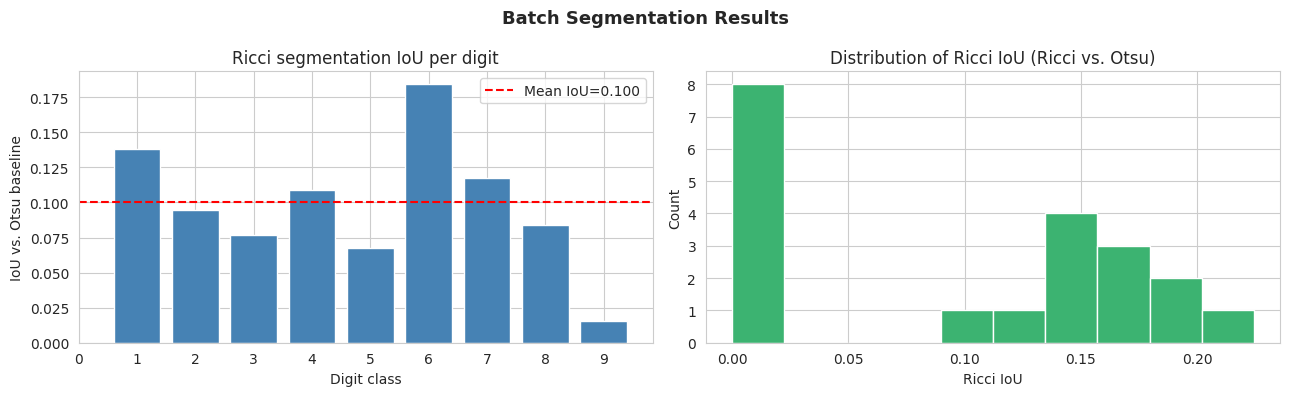

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

digit_iou = results_df.groupby('label')['ricci_iou'].mean()
axes[0].bar(digit_iou.index, digit_iou.values, color='steelblue', edgecolor='white')
axes[0].axhline(results_df['ricci_iou'].mean(), color='red', linestyle='--', label=f"Mean IoU={results_df['ricci_iou'].mean():.3f}")
axes[0].set_xlabel('Digit class')
axes[0].set_ylabel('IoU vs. Otsu baseline')
axes[0].set_title('Ricci segmentation IoU per digit')
axes[0].legend()
axes[0].set_xticks(range(10))

axes[1].hist(results_df['ricci_iou'], bins=10, color='mediumseagreen', edgecolor='white')
axes[1].set_xlabel('Ricci IoU')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Ricci IoU (Ricci vs. Otsu)')

plt.suptitle('Batch Segmentation Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

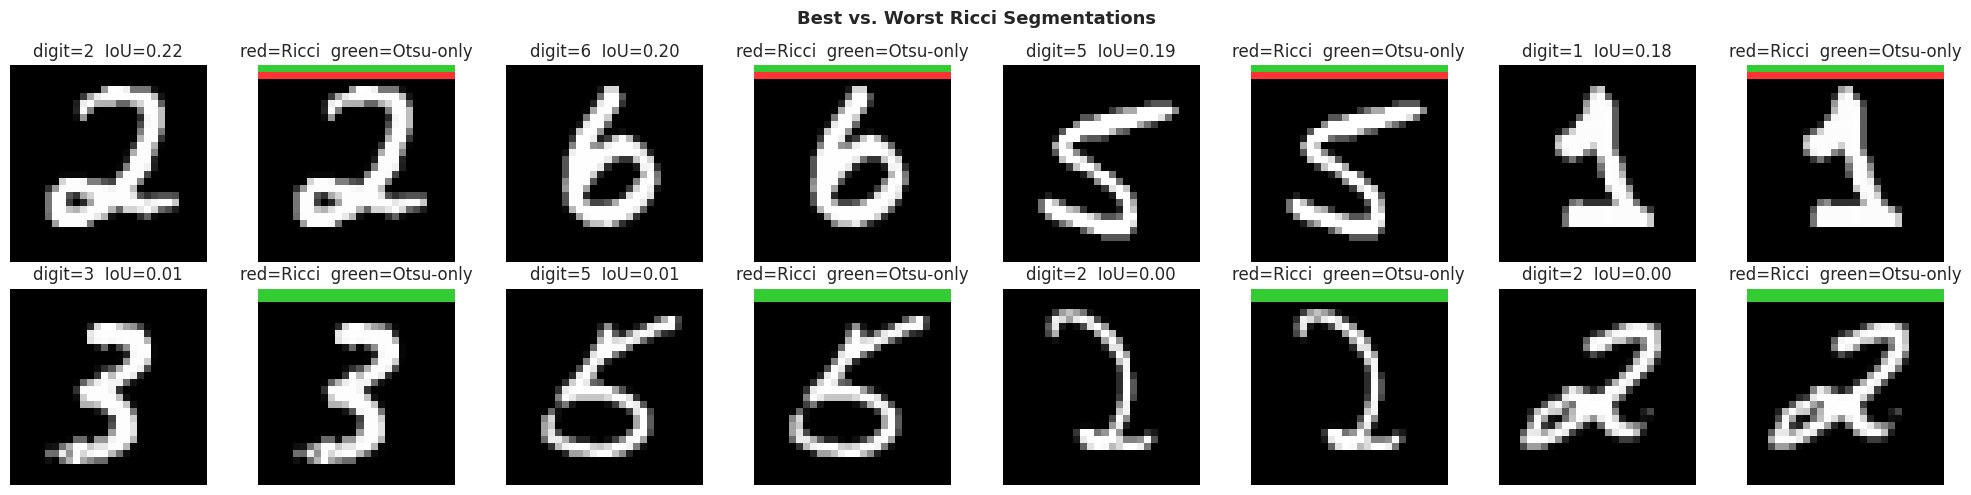

In [27]:
# Show best and worst IoU examples side by side
sorted_df = results_df.sort_values('ricci_iou', ascending=False)
show_n    = min(4, len(sorted_df) // 2)
best_rows  = sorted_df.head(show_n)
worst_rows = sorted_df.tail(show_n)

fig, axes = plt.subplots(2, show_n * 2, figsize=(show_n * 5, 5))
combined  = pd.concat([best_rows, worst_rows]).reset_index(drop=True)

for col, (_, row) in enumerate(combined.iterrows()):
    grp  = 0 if col < show_n else 1
    gcol = col if col < show_n else col - show_n

    img = train_images[int(row['idx'])]
    r_mask_flat, _  = ricci_segment_image(img)
    # Reshape r_mask_flat back to the original image shape for boolean indexing
    r_mask_2d = r_mask_flat.reshape(img.shape)
    otsu_mask  = img > threshold_otsu(img)

    axes[grp, gcol * 2].imshow(img, cmap='gray')
    axes[grp, gcol * 2].set_title(f"digit={int(row['label'])}  IoU={row['ricci_iou']:.2f}")
    axes[grp, gcol * 2].axis('off')

    overlay = np.stack([img]*3, axis=-1)
    overlay[r_mask_2d]              = [1.0, 0.2, 0.2]   # Ricci fg = red
    overlay[otsu_mask & ~r_mask_2d] = [0.2, 0.8, 0.2]   # Otsu-only = green
    axes[grp, gcol * 2 + 1].imshow(overlay)
    axes[grp, gcol * 2 + 1].set_title('red=Ricci  green=Otsu-only')
    axes[grp, gcol * 2 + 1].axis('off')

axes[0, 0].set_ylabel('Best IoU', fontsize=11)
axes[1, 0].set_ylabel('Worst IoU', fontsize=11)
plt.suptitle('Best vs. Worst Ricci Segmentations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Curvature Statistics as Classification Features

Do the **summary statistics of the curvature distribution** differ between digit classes?
We extract 8 features per image (mean, std, min, max, skewness, kurtosis, fraction of negative edges, lower quartile)
and test whether a simple logistic regression can separate digit classes from these alone.

Extracting curvature features using InitialSegmenter.image_to_graph ...


100%|██████████| 20/20 [01:26<00:00,  4.33s/it]

Feature matrix: (20, 8),  classes: [1 2 3 4 5 6 7 8 9]
LR CV accuracy : 0.000 +/- 0.000
Chance level   : 0.111  (9 classes)


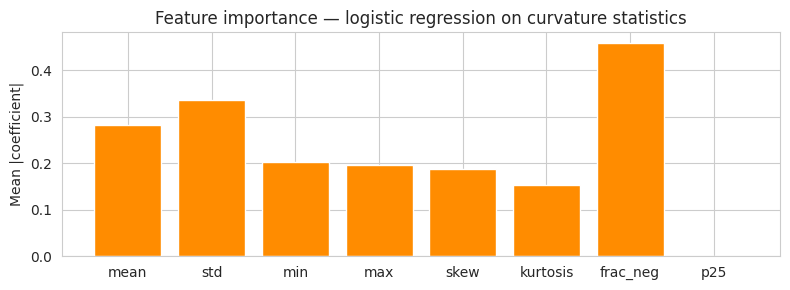

In [28]:
def curvature_features(G, curvature_attr="ricciCurvature") -> np.ndarray:
    """8-dim feature vector from edge curvature distribution."""
    curv = np.array(list(nx.get_edge_attributes(G, curvature_attr).values()))
    if len(curv) == 0:
        return np.zeros(8, dtype=np.float32)
    return np.array([
        curv.mean(), curv.std(), curv.min(), curv.max(),
        skew(curv), kurtosis(curv),
        (curv < 0).mean(),
        np.percentile(curv, 25),
    ], dtype=np.float32)


print("Extracting curvature features using InitialSegmenter.image_to_graph ...")
seg_feat = InitialSegmenter(pixel_dist_function="euclidean")
X_rows, y_rows = [], []

for _, row in tqdm(results_df.iterrows(), total=len(results_df)):
    img   = train_images[int(row["idx"])]
    G_img = seg_feat.image_to_graph(img)
    orc_tmp = OllivierRicci(G_img, verbose="ERROR")
    orc_tmp.compute_ricci_curvature()
    orc_tmp.compute_ricci_flow(iterations=FLOW_ITERATIONS)
    X_rows.append(curvature_features(orc_tmp.G))
    y_rows.append(int(row["label"]))

X, y = np.array(X_rows), np.array(y_rows)
print(f"Feature matrix: {X.shape},  classes: {np.unique(y)}")

X_sc = StandardScaler().fit_transform(X)
clf  = LogisticRegression(max_iter=1000, random_state=42)

min_s    = min(Counter(y).values())
n_splits = min(5, min_s) if min_s >= 2 else 2
cv       = (StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
            if min_s >= 2 else KFold(n_splits=2, shuffle=True, random_state=42))

scores = cross_val_score(clf, X_sc, y, cv=cv, scoring="accuracy")
chance = 1.0 / len(np.unique(y))
print(f"LR CV accuracy : {scores.mean():.3f} +/- {scores.std():.3f}")
print(f"Chance level   : {chance:.3f}  ({len(np.unique(y))} classes)")

clf.fit(X_sc, y)
feature_names = ["mean", "std", "min", "max", "skew", "kurtosis", "frac_neg", "p25"]
coef_abs = np.abs(clf.coef_).mean(axis=0)

plt.figure(figsize=(8, 3))
plt.bar(feature_names, coef_abs, color="darkorange", edgecolor="white")
plt.ylabel("Mean |coefficient|")
plt.title("Feature importance — logistic regression on curvature statistics")
plt.tight_layout()
plt.show()
